# Climate Change Module

## Reproducing the hockey stick, and checking if it is correct

We reproduced the famous hockeystick curve from [Mann et al (1998)](https://doi.org/10.1038/33859). This details that that
recent warming stands outside the range of natural variability over the past several centuries.


You will rebuild that picture from current observations and ice-core records, in the style of
NASA's [vital signs](https://climate.nasa.gov/vital-signs).

A language model will write most of the parsing code. It is good at it, and it is also wrong in
ways that run cleanly and produce a plot. Your job is the question scientists have always had to
answer about code they did not write:

> **How do I know these numbers are right?**

Each part below gives you a data source and a question. It does not tell you what is wrong with
the data. Finding that out is the assignment.




### Verification block

Every dataset gets these five questions answered, in your own words, **before** you plot it.
Each part below ends with one.

1. **Extent** — how many rows, what time range, and does that match the source documentation?
2. **Missing data** — how is it encoded, and did your parser catch it?
3. **Units** — what are they, and where in the source is that stated?
4. **Completeness** — the whole dataset, or one piece of it?
5. **Cross-check** — one value confirmed against an independent source.

---

# Part 1
Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>



In [10]:
import pandas as pd
from plotnine import * 
import pandas as pd

url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

df = pd.read_csv(
    url,
    sep=r"\s+",          # whitespace-delimited
    comment="#",         # skip header/comment lines
    header=None,
    names=[
        "year", "month", "decimal_date",
        "co2_ppm",           # monthly average CO2 (ppm)
        "trend_ppm",         # de-seasonalized (trend) CO2
        "n_days",            # # of days in month
        "stdev_days",        # st.dev of daily values
        "unc_month_mean",    # uncertainty of monthly mean
    ],
)

df.head()


,year,month,decimal_date,co2_ppm,trend_ppm,n_days,stdev_days,unc_month_mean
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


In [18]:
columns = ['year', 'month', 'decimal_date', 'average', 'smooth', 'std_days', 'uncertainty', 'empty']
co2 = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                  sep = '\\s+',
                  comment = '#',
                  header = None,
                  names = columns
                  )
co2

,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
816,2026,3,2026.2083,430.15,428.69,26,0.87,0.33
817,2026,4,2026.2917,431.12,428.62,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.05,17,0.67,0.31
819,2026,6,2026.4583,431.44,429.04,19,0.28,0.12


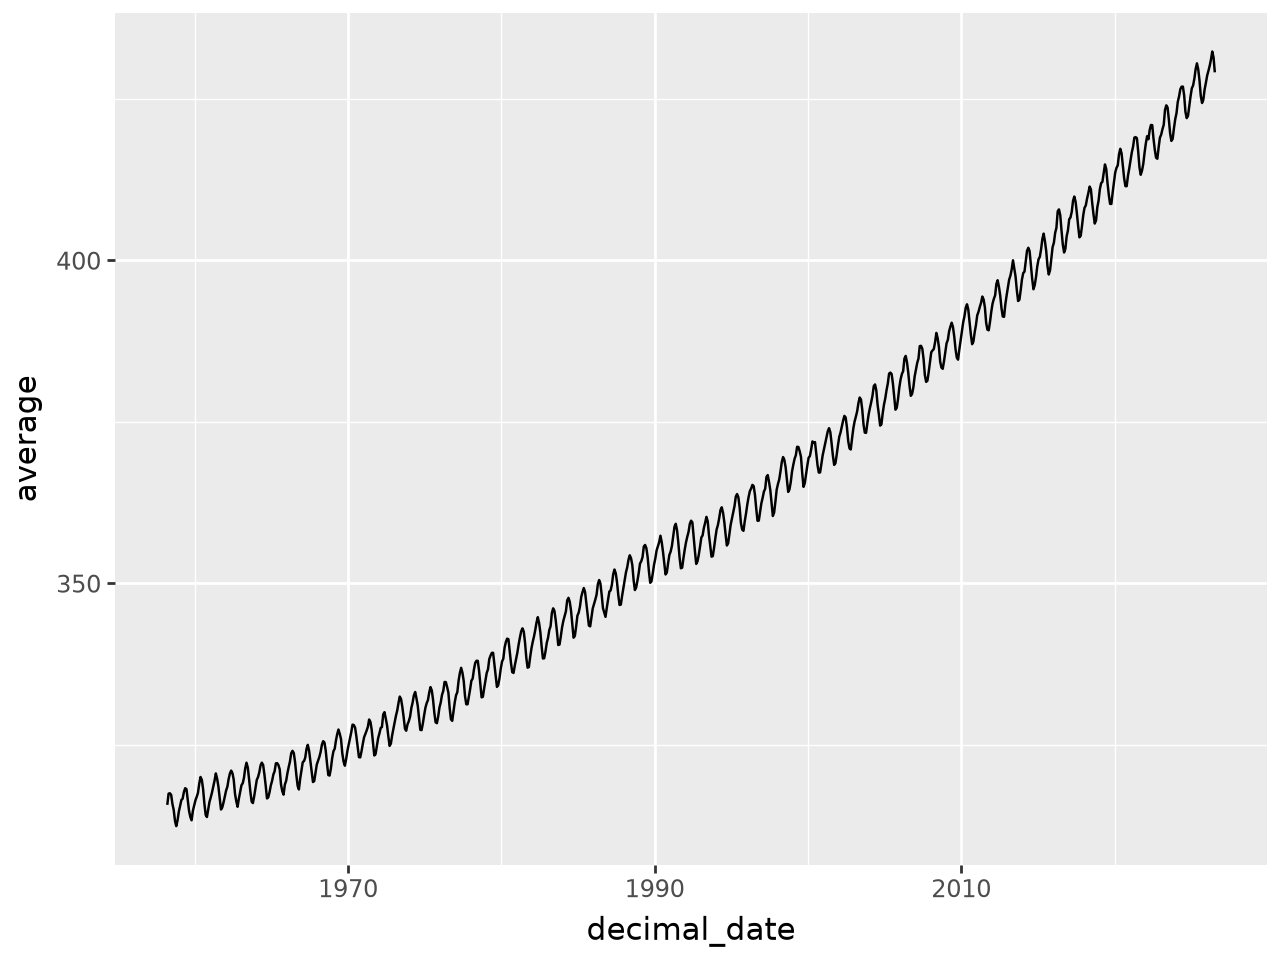

In [12]:
ggplot(df, aes(x="decimal_date", y="average")) + geom_line()

### Task 1.1: Read the source, not the code

That `columns` list was written by hand. Open the raw file and read its header block, then check
every name against what the header says the column holds. Report any that misstate it, and say
which of those would change a published figure if nobody noticed.

4 of 8 column names misstate the source header: smooth→deseasonalized, std_days→day count, uncertainty→daily σ, empty→monthly-mean uncertainty. The last three would inflate error bars, making large bars, or dropping the uncertainty estimate from any published figure. The header is commented out, so read_csv(comment='#') discards the only known fact.

**Your answer:**

### Task 1.2: Missing values

How does this file encode a measurement that was not made? Verify it in the raw file, count the
affected rows per column, and say what a naive `mean()`, `min()`, or error bar would report if you
left them in. State what you did about it and why.

The header states that missing measurements are encoded as negative sentinel values, not blanks: #days = -1 (195 rows), st.dev = -9.99 (196 rows), unc = -0.99 (194 rows, plus 0.00 for the 2 interpolated months Dec 1975 and Apr 1984). The average column is never blank — missing months are filled by interpolation, so "missing" shows up only in the last three columns.

Left in, naive statistics go wrong and look credible: mean() returns −2.0 ppm for st.dev (true ~0.5) and −0.085 for unc. (true ~0.2), min() returns −9.99, and error bars render negative widths. I masked all < 0 values to NaN, computed summaries on valid values only, and flagged (but did not delete) the interpolated months — keeping the data while removing the sentinels, since the missing/information distinction (SIO vs. NOAA) is real.


**Your answer:**

### Task 1.3: What the numeric columns cannot tell you

The header block contains prose notes as well as column definitions. Read them.

Does anything there change how you would plot or interpret this series? Show your evidence in the
data rather than asserting it, and say whether a model reading only the numeric columns would have
any way to know.

**Your answer:**

### Task 1.4: Check whether a better door exists

Before you fix a parser, find out whether you need one. NOAA distributes this same monthly record
in more than one format: <https://gml.noaa.gov/ccgg/trends/data.html>

Load an alternative distribution. Which of the problems you found above does switching formats
solve, and which does it not?

**Your answer:**

### Task 1.5: The other library

Now try to load the original `.txt` with `ibis` instead of `pandas`. Report what happens.

Explain the result in terms of the *file*, not the library. What does it do to a rule like "always
use `ibis`"?

The header states that missing measurements are encoded as negative sentinel values, not blanks: #days = -1 (195 rows), st.dev = -9.99 (196 rows), unc = -0.99 (194 rows, plus 0.00 for the 2 interpolated months Dec 1975 and Apr 1984). The average column is never blank — missing months are filled by interpolation, so "missing" shows up only in the last three columns.

Left in, naive statistics go wrong and look credible: mean() returns −2.0 ppm for st.dev (true ~0.5) and −0.085 for unc. (true ~0.2), min() returns −9.99, and error bars render negative widths. I masked all < 0 values to NaN, computed summaries on valid values only, and flagged (but did not delete) the interpolated months — keeping the data while removing the sentinels, since the missing/information distinction (SIO vs. NOAA) is real.


**Your answer:**

### 🔍 Verification block 1

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Arctic sea ice

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>


Prompt used to guide the LLM:
```
Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>
load Arctic sea ice extent and plot the
trend. 
```

In [29]:
import pandas as pd
from plotnine import *

base = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_{:02d}_extent_v4.0.csv"
df = pd.concat([pd.read_csv(base.format(mo)) for mo in range(1, 13)], ignore_index=True)
df.columns = df.columns.str.strip()
df["extent"] = df["extent"].replace(-9999, float("nan"))
df["area"] = df["area"].replace(-9999, float("nan"))
df

,year,mo,source_dataset,region,extent,area
0,1979,1,NSIDC-0051,N,15.41,12.41
1,1980,1,NSIDC-0051,N,14.86,11.94
2,1981,1,NSIDC-0051,N,14.91,11.91
3,1982,1,NSIDC-0051,N,15.18,12.19
4,1983,1,NSIDC-0051,N,14.94,12.01
...,...,...,...,...,...,...
569,2021,12,NSIDC-0051,N,12.15,10.74
570,2022,12,NSIDC-0051,N,11.89,10.27
571,2023,12,NSIDC-0051,N,11.98,10.34
572,2024,12,NSIDC-0051,N,11.41,10.03


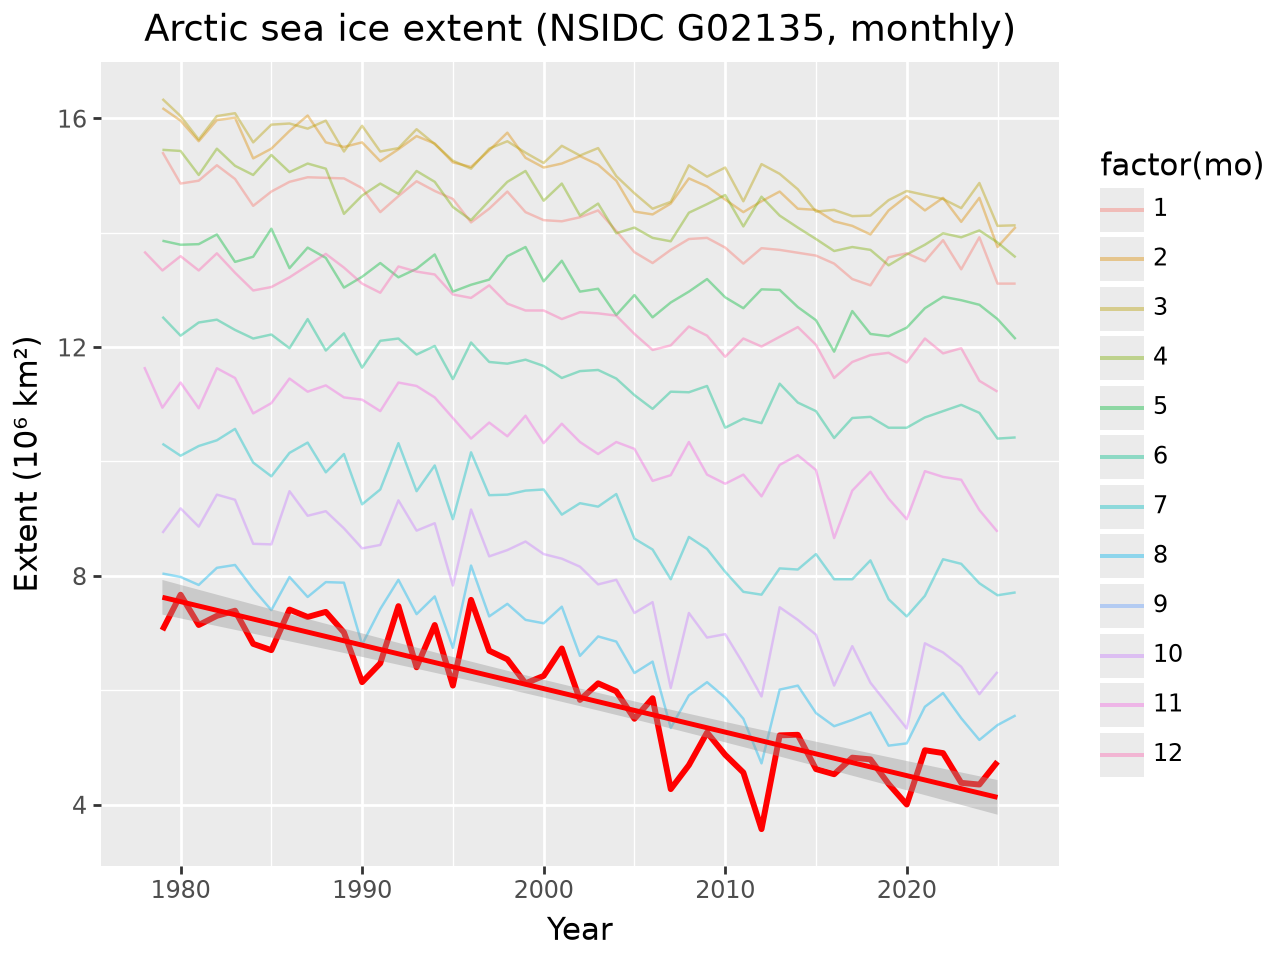

In [30]:
(ggplot(df[df.extent.notna()], aes("year", "extent"))
 + geom_line(aes(group="mo", color="factor(mo)"), alpha=0.4)
 + geom_line(data=df[df.mo == 9].dropna(subset=["extent"]), color="red", size=1.2)
 + geom_smooth(data=df[df.mo == 9].dropna(subset=["extent"]), method="lm", se=True, color="red")
 + labs(y="Extent (10⁶ km²)", x="Year", title="Arctic sea ice extent (NSIDC G02135, monthly)"))

### Task 2.2: What did it actually load?

Now open the data directory and look at what is there.

Check the URL the model's code used against the directory listing *before* you run anything. Did
it point at a file that exists? If it ran, how much of the record does the plot actually show, and
is the title honest? If it failed, would you have predicted that failure from reading the code?

A model that has never seen this directory still has to produce a filename. Note where it got one.

For both the table and the graph, the model referred to the files for its data. The file it pointed to did exist and everything appears to be honest.

### Task 2.3: Build the complete record

Load the full dataset and plot sea ice extent over time.

Then make a scientific decision and defend it: the September minimum is the standard index for
Arctic sea ice loss, and it is not the same thing as the annual mean. Which does your analysis
report, and why is that right for the question you are asking?

In [35]:
import numpy as np
def slope(x, y):  # 10⁶ km² per decade
    return np.polyfit(x, y, 1)[0] * 10

print("September minimum:", round(slope(sep.year, sep.extent), 2), "10⁶ km²/decade")
print("Annual mean:      ", round(slope(annual.year, annual.extent), 2), "10⁶ km²/decade")

September minimum: -0.76 10⁶ km²/decade
Annual mean:       -0.48 10⁶ km²/decade


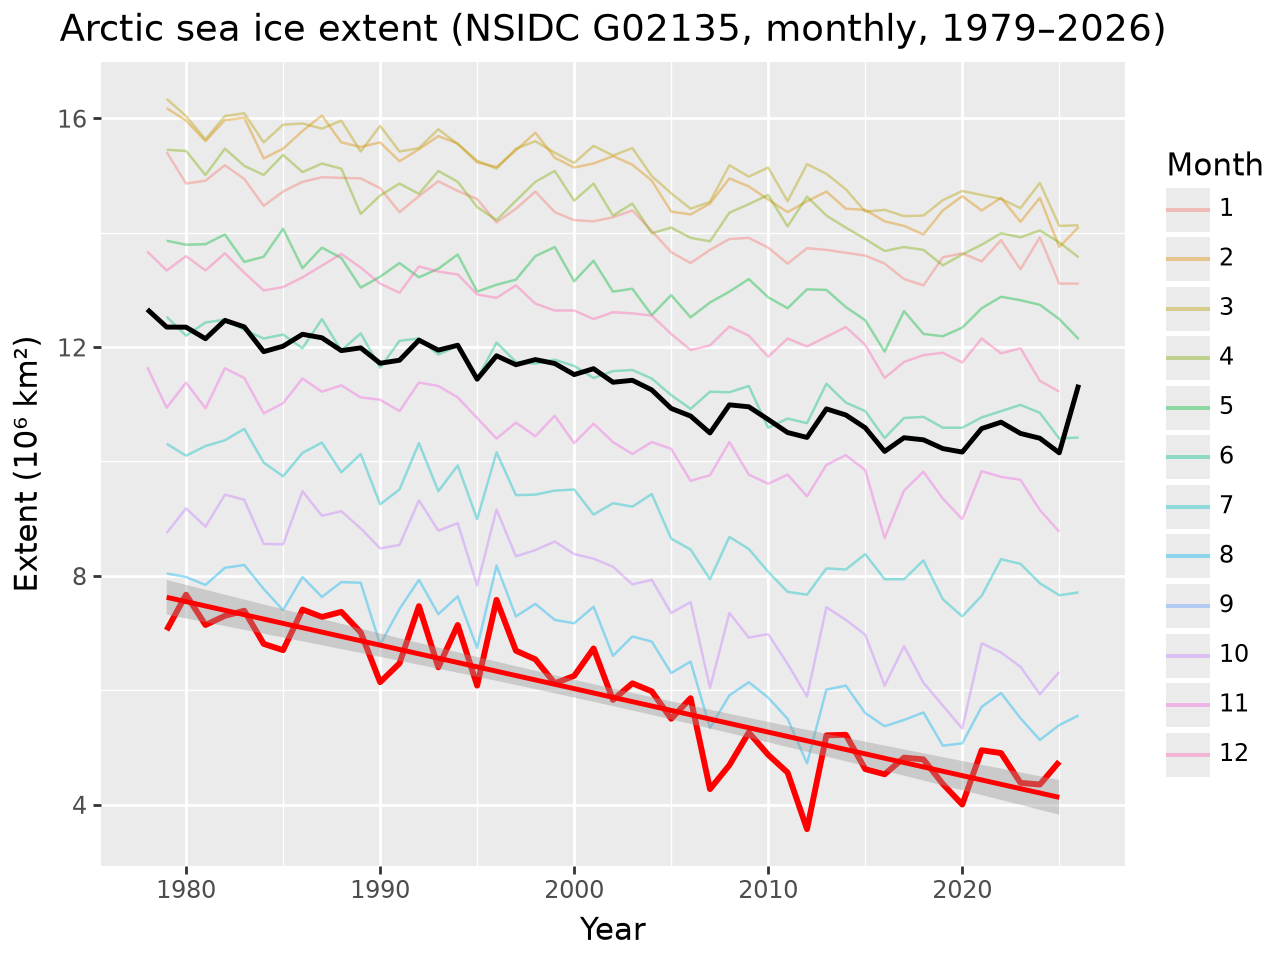

In [36]:
annual = df.groupby("year").extent.mean().reset_index()
sep = df[df.mo == 9].dropna(subset=["extent"])

(ggplot(df[df.extent.notna()], aes("year", "extent"))
 + geom_line(aes(group="mo", color="factor(mo)"), alpha=0.4)
 + geom_line(data=sep, color="red", size=1.2)
 + geom_line(data=annual, color="black", size=1)
 + geom_smooth(data=sep, method="lm", se=True, color="red")
 + labs(y="Extent (10⁶ km²)", x="Year",
         title="Arctic sea ice extent (NSIDC G02135, monthly, 1979–2026)",
         color="Month"))



The analysis reports the September minimum. It is the standard index for Arctic sea ice loss because it measures the summer ice that survives the melt season — where warming acts — while the annual mean dilutes that signal with the slowly-declining winter maximum. Here the difference is real: September trends −0.76 ×10⁶ km²/decade vs −0.48 for the annual mean, so the mean would understate the loss. Reporting September also matches NSIDC's published record (Sept 2012: 3.57, Sept 2020: 4.00). The annual mean is shown only to make clear it is not the same quantity. 

### 🔍 Verification block 2

Extent: valid range 3.57–16.34 ×10⁶ km². September 2012 = 3.57 (record low, matches NSIDC's published monthly average; the 3.41 figure is the daily minimum, a different metric) and September 1980 = 7.67 (record high).

Missing data: exactly 2 of 576 slots are -9999 → December 1987 and January 1988 (the documented satellite data gap in the SSM/I record). In the loaded frame they become NaN; both dropped by the plot.

Units: both extent and area are in 10⁶ km² (million km²), confirmed from the G02135 documentation; area < extent always (area excludes <15% concentration).

Completeness: record runs Nov 1978 – Aug 2026 (574 rows = 2 in 1978 + 47×12 + 8), not 1979 — so their plot title should say 1978. 2026 stops at August (September not yet published; current date Sep 2026). source_dataset switches from NSIDC-0051 to NSIDC-0803 in Jan 2025 (20 rows), i.e. v4.0's new concentration source — worth noting as an instrument change, not a data error.

Cross-check: September 2007 = 4.27, 2012 = 3.57, 2020 = 4.00, 2016 = 4.53 — all match NSIDC's published monthly-average values. One gotcha: string columns have leading spaces (' N', ' NSIDC-0051'), so df[df.region == "N"] would silently return zero rows — strip values, not just column names, if filtering.

---

# Part 3: Emissions by industry

[EXIOBASE](https://www.exiobase.eu/) is a multi-regional, environmentally-extended input-output
database: economic flows between industries and regions worldwide, with the emissions attached to
them. It lets you ask which *industries* drive emissions, not just which countries.

We use the cloud-optimized Parquet copy at
[source.coop/youssef-harby/exiobase-3](https://source.coop/youssef-harby/exiobase-3). The
inter-industry transaction table `Z` for one year:

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet
```

### Task 3.1: Ask without guidance

Ask your model to compute total industrial output by origin region for 2022 from that file. Do not
tell it which library to use.

**Record the prompt you used:**

```
[paste your prompt here]
```

**Which library did it choose, unprompted?**

### Task 3.2: Measure what it cost

Run the code it wrote inside the harness below, which reports peak memory and wall time. Your
session has roughly **4 GB of RAM**. Report what happens, including if it does not finish.

In [24]:
import resource, time, contextlib

@contextlib.contextmanager
def measure(label):
    t0 = time.time()
    try:
        yield
    finally:
        peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024**2
        print(f"{label}: peak memory {peak:.2f} GB, elapsed {time.time() - t0:.1f}s")

# with measure("pandas"):
#     result = ...

### Task 3.3: Now constrain it

Ask again, this time requiring `ibis` with the DuckDB backend. Measure the same way.

| approach | peak memory | elapsed | did it finish? |
|---|---|---|---|
| unguided | | | |
| ibis / duckdb | | | |

**Do the two approaches give the same answer?** Check, do not assume. If they disagree, that is a
finding worth more than either number alone.

### Task 3.4: Why did it choose that?

Why does a model, asked to analyze data with no further guidance, reach for the library it
reached for? Consider what its training data looks like.

- What does it mean that the tool most likely to be *suggested* is the one most represented in
  code written years ago?
- On the evidence of this exercise, what is the human actually contributing?
- What would have happened if nobody in the room knew the alternative existed?
- In Task 1.5 you found the reverse case. State the rule that covers both, without naming a
  library.

**Your answer:**

---

# Part 4: Which CO2?

The `F_satellite` table holds the environmental extensions — emissions and resource flows attached
to each industry and region.

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet
```

### Task 4.1: Survey before you filter

Load the table. Before writing any filter, report how many distinct values the `stressor` column
contains, how many of them mention CO2 (with their units and totals), and how many distinct units
appear in the `unit` column across the whole table.

**Your answer:**

### Task 4.2: What did you just add together?

Group by region and sum `value` across all stressors. Then look at what that sum contains.

How many different units went into it? Is the result a mass, a volume, a currency, or a number
with no meaning? What is the ratio between the two most common units, and what would mixing them
do to a national total?

**Your answer:**

### Task 4.3: Choose your stressors, and defend the choice

Compute total CO2 emissions by region for 2022.

You must decide which stressors belong in that total. This is a scientific judgment, not a
string-matching exercise: filtering too narrowly omits real emissions, and matching every name
containing `"CO2"` includes flows that standard greenhouse-gas accounting deliberately excludes.
Find out which, and on what grounds.

Ask your model which to include, then check its reasoning against the accounting convention.

**Which stressors did you include, and why? Which did you exclude, and why?**

### Task 4.4: Reconcile against an independent source

Compare your EXIOBASE national totals against Our World in Data:
<https://github.com/owid/co2-data/raw/master/owid-co2-data.csv>

They will not match. Pick one country and quantify the gap:

| | value | units |
|---|---|---|
| OWID total | | |
| Your EXIOBASE total | | |
| Absolute difference | | |
| Relative difference | | |

Then explain it. The two sources do not measure the same thing — establish what each one actually
counts before you attribute the gap to anything. Candidates to test rather than assert: accounting
scope, gas coverage, sectoral boundaries, your stressor set from 4.3, and year alignment.

**A country that imports most of its manufactured goods should show a particular direction of gap.
Does yours? What does that tell you about the two accounting systems?**

**Your reconciliation:**

### 🔍 Verification block 3

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 5: The hockey stick

Instrumental records cover roughly the last century and a half. To judge whether recent change is
unusual you need a longer baseline, which means proxy records rather than thermometers.

**Vostok ice core**, back roughly 400,000 years:

- Description: <https://cdiac.ess-dive.lbl.gov/trends/co2/vostok.html>
- Data: <https://doi.org/10.3334/CDIAC/ATG.009>

### Task 5.1: Load the ice core record

Load it, and read its documentation carefully enough to say what its index actually is and how it
is sampled. Both bear on what you can legitimately plot next to a modern monthly series.

### Task 5.2: Put modern CO2 in geological context

Combine the Vostok record with the Mauna Loa series from Part 1 in a single figure.

Getting this figure to be *honest* is the hard part:

- The two series have very different sampling resolution. What does a shared axis imply that may
  not be true?
- Where do the records join, and are they measuring the same quantity the same way?
- What does the modern value look like against the full 400,000-year range?

### Task 5.3: Interpret

Relative to [Mann et al (1998)](https://doi.org/10.1038/33859):

- Does your reconstruction support the paper's central claim?
- Where does it differ, and why — more recent data, different proxies, different processing?
- What in your figure is a genuine finding, and what is an artifact of a choice you made?

**Your interpretation:**

---

# Part 6: Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Your reflection:**

1.
2.
3.
4.
5.

---

## Submission

- [ ] Notebook runs top to bottom without errors
- [ ] All three verification blocks completed
- [ ] Prompts recorded where asked (Tasks 2.1, 3.1)
- [ ] Memory and timing table filled in (Task 3.3)
- [ ] Stressor selection defended (Task 4.3) and reconciliation quantified (Task 4.4)
- [ ] Hockey stick figure with the modern record in geological context (Task 5.2)
- [ ] Reflection complete (Part 6)
- [ ] README updated with team members, badge, and description
- [ ] Repository passes its GitHub Actions check

See [rubric.md](rubric.md) for scoring.